In [1]:
# Cell 1 — Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
from dotenv import load_dotenv

# settings for better looking charts
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# Cell 2 — Connect to MySQL and load all main tables
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

# create connection
password = quote_plus(os.getenv('DB_PASSWORD'))
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}",
    pool_pre_ping=True
)

# load all main tables from MySQL into Pandas DataFrames
orders       = pd.read_sql("SELECT * FROM orders", engine)
customers    = pd.read_sql("SELECT * FROM customers", engine)
order_items  = pd.read_sql("SELECT * FROM order_items", engine)
payments     = pd.read_sql("SELECT * FROM order_payments", engine)
reviews      = pd.read_sql("SELECT * FROM order_reviews", engine)
products     = pd.read_sql("SELECT * FROM products", engine)
sellers      = pd.read_sql("SELECT * FROM sellers", engine)

print(" All tables loaded successfully!")
print(f" Orders:      {orders.shape[0]:,} rows, {orders.shape[1]} columns")
print(f" Customers:   {customers.shape[0]:,} rows, {customers.shape[1]} columns")
print(f" Order Items: {order_items.shape[0]:,} rows, {order_items.shape[1]} columns")
print(f" Payments:    {payments.shape[0]:,} rows, {payments.shape[1]} columns")
print(f" Reviews:     {reviews.shape[0]:,} rows, {reviews.shape[1]} columns")
print(f" Products:    {products.shape[0]:,} rows, {products.shape[1]} columns")
print(f" Sellers:     {sellers.shape[0]:,} rows, {sellers.shape[1]} columns")

 All tables loaded successfully!
 Orders:      99,441 rows, 8 columns
 Customers:   99,441 rows, 5 columns
 Order Items: 112,650 rows, 7 columns
 Payments:    103,886 rows, 5 columns
 Reviews:     99,224 rows, 7 columns
 Products:    32,951 rows, 9 columns
 Sellers:     3,095 rows, 4 columns


In [4]:
# Cell 3 — First look at orders table
print("ORDERS TABLE — First 5 rows:")
print(orders.head())
print("\n")
print("Column names:")
print(orders.columns.tolist())
print("\n")
print("Data types of each column:")
print(orders.dtypes)
print("\n")
print("Basic statistics:")
print(orders.describe())

ORDERS TABLE — First 5 rows:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-

In [5]:
# Cell 4 — Find missing values in every table
print("=== MISSING VALUES CHECK ===\n")

tables = {
    'orders': orders,
    'customers': customers,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers
}

for name, df in tables.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

=== MISSING VALUES CHECK ===

orders: 4908 missing values
customers: 0 missing values
order_items: 0 missing values
payments: 0 missing values
reviews: 145903 missing values
products: 2448 missing values
sellers: 0 missing values


In [6]:
# Cell 5 — Order status breakdown
print("=== ORDER STATUS BREAKDOWN ===\n")
status_counts = orders['order_status'].value_counts()
print(status_counts)
print(f"\nTotal orders: {len(orders):,}")
print(f"Delivered: {status_counts.get('delivered', 0):,}")
print(f"Cancelled: {status_counts.get('canceled', 0):,}")
print(f"Cancellation rate: {status_counts.get('canceled', 0)/len(orders)*100:.2f}%")

=== ORDER STATUS BREAKDOWN ===

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total orders: 99,441
Delivered: 96,478
Cancelled: 625
Cancellation rate: 0.63%


In [8]:
# Cell 6 — Calculate revenue lost from cancelled and unavailable orders

# Step 1 — convert date columns from text to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print(" Dates converted to datetime")

# Step 2 — get all cancelled and unavailable orders
lost_orders = orders[orders['order_status'].isin(['canceled', 'unavailable'])]
print(f"\n Total incomplete orders: {len(lost_orders):,}")
print(f"   Cancelled:   {len(orders[orders['order_status'] == 'canceled']):,}")
print(f"   Unavailable: {len(orders[orders['order_status'] == 'unavailable']):,}")

# Step 3 — join with payments to find the money value
lost_revenue = lost_orders.merge(payments, on='order_id', how='left')

# Step 4 — calculate total revenue lost
total_lost = lost_revenue['payment_value'].sum()
avg_lost_per_order = lost_revenue['payment_value'].mean()
max_lost_order = lost_revenue['payment_value'].max()

print(f"\n REVENUE LEAKAGE FROM INCOMPLETE ORDERS:")
print(f"   Total revenue lost:        R$ {total_lost:,.2f}")
print(f"   Average lost per order:    R$ {avg_lost_per_order:,.2f}")
print(f"   Highest single lost order: R$ {max_lost_order:,.2f}")

# Step 5 — compare against total revenue
total_revenue = payments['payment_value'].sum()
leakage_pct = (total_lost / total_revenue) * 100

print(f"\n CONTEXT:")
print(f"   Total platform revenue:    R$ {total_revenue:,.2f}")
print(f"   Revenue lost:              R$ {total_lost:,.2f}")
print(f"   Leakage percentage:        {leakage_pct:.2f}%")

 Dates converted to datetime

 Total incomplete orders: 1,234
   Cancelled:   625
   Unavailable: 609

 REVENUE LEAKAGE FROM INCOMPLETE ORDERS:
   Total revenue lost:        R$ 269,735.11
   Average lost per order:    R$ 205.43
   Highest single lost order: R$ 4,809.44

 CONTEXT:
   Total platform revenue:    R$ 16,008,872.12
   Revenue lost:              R$ 269,735.11
   Leakage percentage:        1.68%


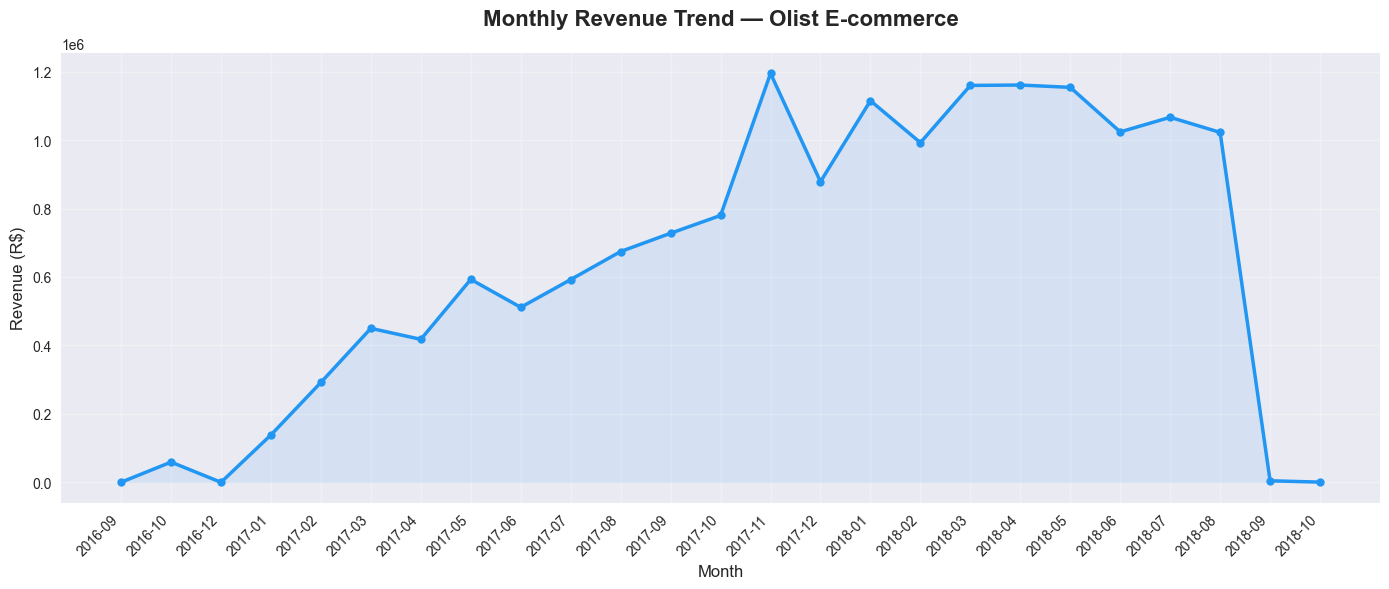


📊 Monthly Revenue Summary:
Best month:  2017-11 — R$ 1,194,882.80
Worst month: 2016-12 — R$ 19.62
Average monthly revenue: R$ 640,354.88


In [ ]:
# Cell 7 — Monthly revenue trend chart

# Step 1 — add month column to orders
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Step 2 — merge orders with payments
orders_payments = orders.merge(payments, on='order_id', how='inner')

# Step 3 — group by month and sum revenue
monthly_revenue = orders_payments.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

# Step 4 — plot the chart
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['order_month'], 
         monthly_revenue['payment_value'], 
         marker='o', linewidth=2.5, 
         color='#2196F3', markersize=6)

plt.fill_between(range(len(monthly_revenue)), 
                 monthly_revenue['payment_value'], 
                 alpha=0.1, color='#2196F3')

plt.title('Monthly Revenue Trend — Olist E-commerce', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (R$)', fontsize=12)
plt.xticks(range(len(monthly_revenue)), 
           monthly_revenue['order_month'], 
           rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/monthly_revenue_trend.png', dpi=150)
plt.show()

print("\n Monthly Revenue Summary:")
print(f"Best month:  {monthly_revenue.loc[monthly_revenue['payment_value'].idxmax(), 'order_month']} — R$ {monthly_revenue['payment_value'].max():,.2f}")
print(f"Worst month: {monthly_revenue.loc[monthly_revenue['payment_value'].idxmin(), 'order_month']} — R$ {monthly_revenue['payment_value'].min():,.2f}")
print(f"Average monthly revenue: R$ {monthly_revenue['payment_value'].mean():,.2f}")

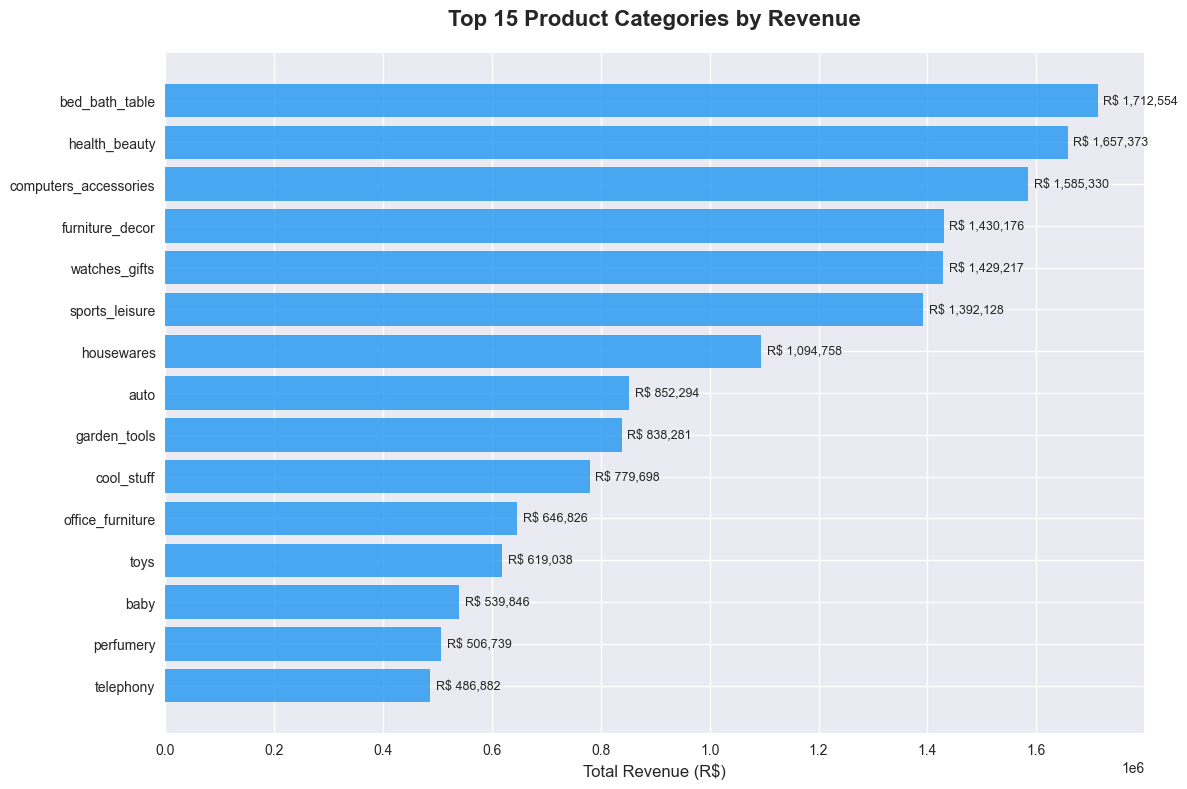


 Top 5 Revenue Categories:
  1. bed_bath_table: R$ 1,712,553.67
  2. health_beauty: R$ 1,657,373.12
  3. computers_accessories: R$ 1,585,330.45
  4. furniture_decor: R$ 1,430,176.39
  5. watches_gifts: R$ 1,429,216.68


In [11]:
# Cell 8 — Top product categories by revenue

# Step 1 — load category translation
category = pd.read_sql("SELECT * FROM product_category_translation", engine)

# Step 2 — merge order_items → products → category translation
items_products = order_items.merge(products, on='product_id', how='left')
items_products = items_products.merge(category, on='product_category_name', how='left')

# Step 3 — merge with payments to get revenue
items_revenue = items_products.merge(
    orders_payments[['order_id','payment_value']], 
    on='order_id', how='left'
)

# Step 4 — group by category and sum revenue
category_revenue = items_revenue.groupby(
    'product_category_name_english'
)['payment_value'].sum().sort_values(ascending=False).head(15)

# Step 5 — plot horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(category_revenue)), 
                category_revenue.values,
                color='#2196F3', alpha=0.8)

plt.yticks(range(len(category_revenue)), category_revenue.index)
plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.title('Top 15 Product Categories by Revenue', 
          fontsize=16, fontweight='bold', pad=20)

# add value labels on bars
for i, (bar, val) in enumerate(zip(bars, category_revenue.values)):
    plt.text(val + 10000, i, f'R$ {val:,.0f}', 
             va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/top_categories_revenue.png', dpi=150)
plt.show()

print("\n Top 5 Revenue Categories:")
for i, (cat, rev) in enumerate(category_revenue.head(5).items(), 1):
    print(f"  {i}. {cat}: R$ {rev:,.2f}")

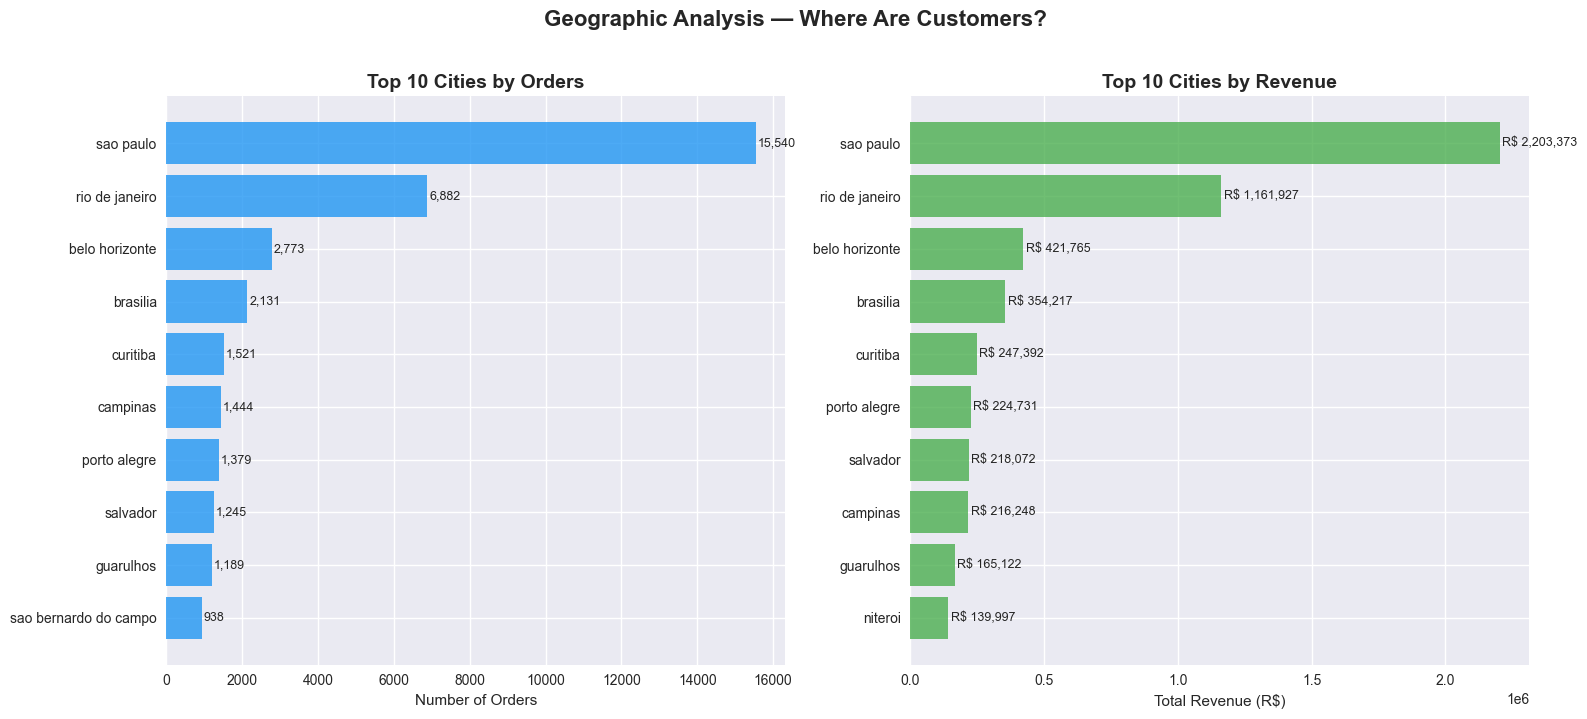


 Top 10 Cities by Orders:
  1. sao paulo: 15,540 orders
  2. rio de janeiro: 6,882 orders
  3. belo horizonte: 2,773 orders
  4. brasilia: 2,131 orders
  5. curitiba: 1,521 orders
  6. campinas: 1,444 orders
  7. porto alegre: 1,379 orders
  8. salvador: 1,245 orders
  9. guarulhos: 1,189 orders
  10. sao bernardo do campo: 938 orders

 Top 10 Cities by Revenue:
  1. sao paulo: R$ 2,203,373.09
  2. rio de janeiro: R$ 1,161,927.36
  3. belo horizonte: R$ 421,765.12
  4. brasilia: R$ 354,216.78
  5. curitiba: R$ 247,392.48
  6. porto alegre: R$ 224,731.42
  7. salvador: R$ 218,071.50
  8. campinas: R$ 216,248.43
  9. guarulhos: R$ 165,121.99
  10. niteroi: R$ 139,996.99


In [14]:
# Cell 9 — Top cities by orders and revenue

# Step 1 — merge orders with customers to get city
orders_customers = orders.merge(customers, on='customer_id', how='left')

# Step 2 — count orders per city
city_orders = orders_customers.groupby(
    'customer_city'
)['order_id'].count().sort_values(ascending=False).head(10)

# Step 3 — get revenue per city
city_revenue = orders_customers.merge(
    payments, on='order_id', how='left'
).groupby('customer_city')['payment_value'].sum().sort_values(ascending=False).head(10)

# Step 4 — plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# chart 1 — orders by city
axes[0].barh(range(len(city_orders)), city_orders.values, color='#2196F3', alpha=0.8)
axes[0].set_yticks(range(len(city_orders)))
axes[0].set_yticklabels(city_orders.index)
axes[0].set_title('Top 10 Cities by Orders', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].invert_yaxis()
for i, val in enumerate(city_orders.values):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

# chart 2 — revenue by city
axes[1].barh(range(len(city_revenue)), city_revenue.values, color='#4CAF50', alpha=0.8)
axes[1].set_yticks(range(len(city_revenue)))
axes[1].set_yticklabels(city_revenue.index)
axes[1].set_title('Top 10 Cities by Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Revenue (R$)')
axes[1].invert_yaxis()
for i, val in enumerate(city_revenue.values):
    axes[1].text(val + 10000, i, f'R$ {val:,.0f}', va='center', fontsize=9)

plt.suptitle('Geographic Analysis — Where Are Customers?', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/city_analysis.png', dpi=150)
plt.show()

print("\n Top 10 Cities by Orders:")
for i, (city, count) in enumerate(city_orders.head(10).items(), 1):
    print(f"  {i}. {city}: {count:,} orders")

print("\n Top 10 Cities by Revenue:")
for i, (city, rev) in enumerate(city_revenue.head(10).items(), 1):
    print(f"  {i}. {city}: R$ {rev:,.2f}")

 PAYMENT METHOD ANALYSIS:
payment_type  total_orders  total_revenue  avg_payment
 credit_card         76795    12542084.19   163.319021
      boleto         19784     2869361.27   145.034435
     voucher          5775      379436.87    65.703354
  debit_card          1529      217989.79   142.570170
 not_defined             3           0.00     0.000000


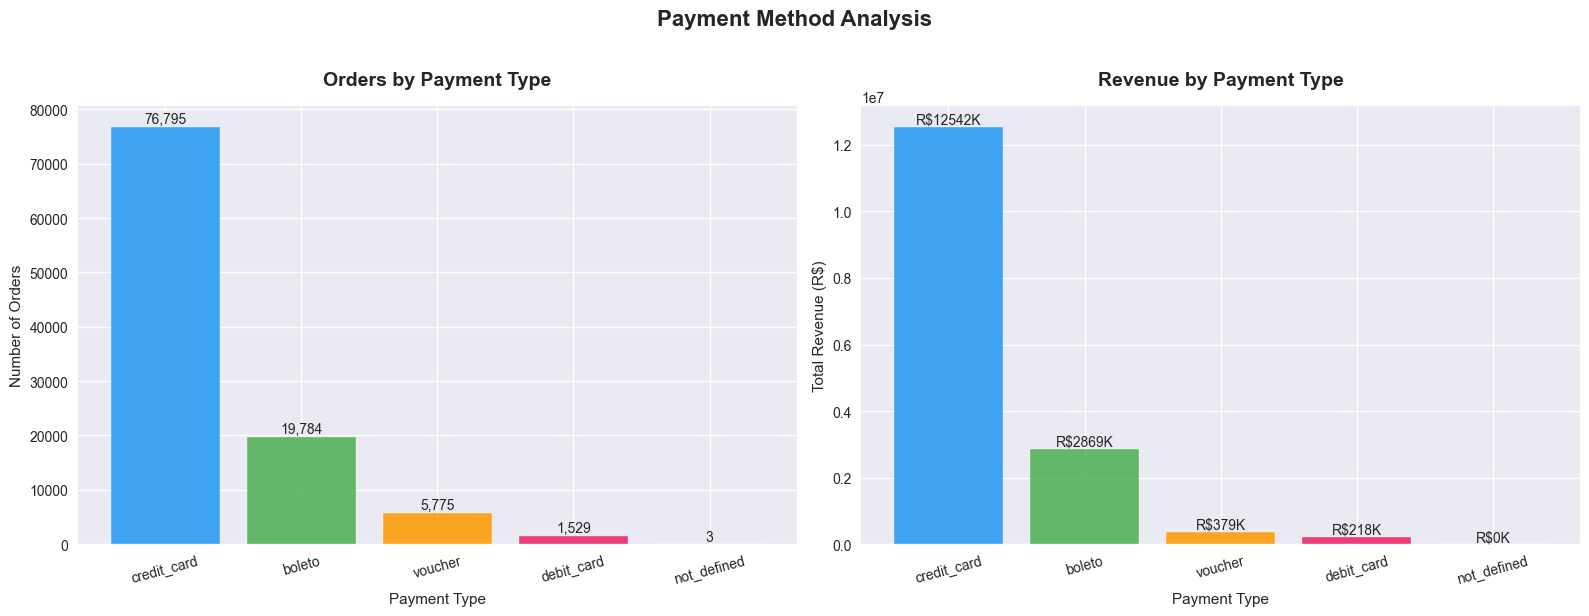


 INSTALMENT ANALYSIS:
Most common instalment count: 1
Max instalments used:         24
Avg payment value 1 instalment:  R$ 112.42
Avg payment value 10 instalments: R$ 415.09


In [18]:
# Cell 10 FIXED — Payment method breakdown

# Step 1 — count and sum by payment type
payment_analysis = payments.groupby('payment_type').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('payment_value', 'sum'),
    avg_payment=('payment_value', 'mean')
).sort_values('total_revenue', ascending=False).reset_index()

print(" PAYMENT METHOD ANALYSIS:")
print(payment_analysis.to_string(index=False))

# Step 2 — bar charts instead of pie (cleaner)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

# chart 1 — orders by payment type
bars1 = axes[0].bar(
    payment_analysis['payment_type'],
    payment_analysis['total_orders'],
    color=colors, alpha=0.85, edgecolor='white'
)
axes[0].set_title('Orders by Payment Type', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Payment Type', fontsize=11)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars1, payment_analysis['total_orders']):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# chart 2 — revenue by payment type
bars2 = axes[1].bar(
    payment_analysis['payment_type'],
    payment_analysis['total_revenue'],
    color=colors, alpha=0.85, edgecolor='white'
)
axes[1].set_title('Revenue by Payment Type', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Payment Type', fontsize=11)
axes[1].set_ylabel('Total Revenue (R$)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, payment_analysis['total_revenue']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5000,
                 f'R${val/1000:.0f}K', ha='center', va='bottom', fontsize=10)

plt.suptitle('Payment Method Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 3 — instalment analysis
print("\n INSTALMENT ANALYSIS:")
print(f"Most common instalment count: {payments['payment_installments'].mode()[0]}")
print(f"Max instalments used:         {payments['payment_installments'].max()}")
print(f"Avg payment value 1 instalment:  R$ {payments[payments['payment_installments']==1]['payment_value'].mean():,.2f}")
print(f"Avg payment value 10 instalments: R$ {payments[payments['payment_installments']==10]['payment_value'].mean():,.2f}")

 DELIVERY TIME ANALYSIS:
Average delivery time:       12.1 days
Fastest delivery:            0.0 days
Slowest delivery:            209.0 days
Average estimated delivery:  23.4 days

On-time deliveries:  89,936
Late deliveries:     6,534
Late delivery rate:  6.8%


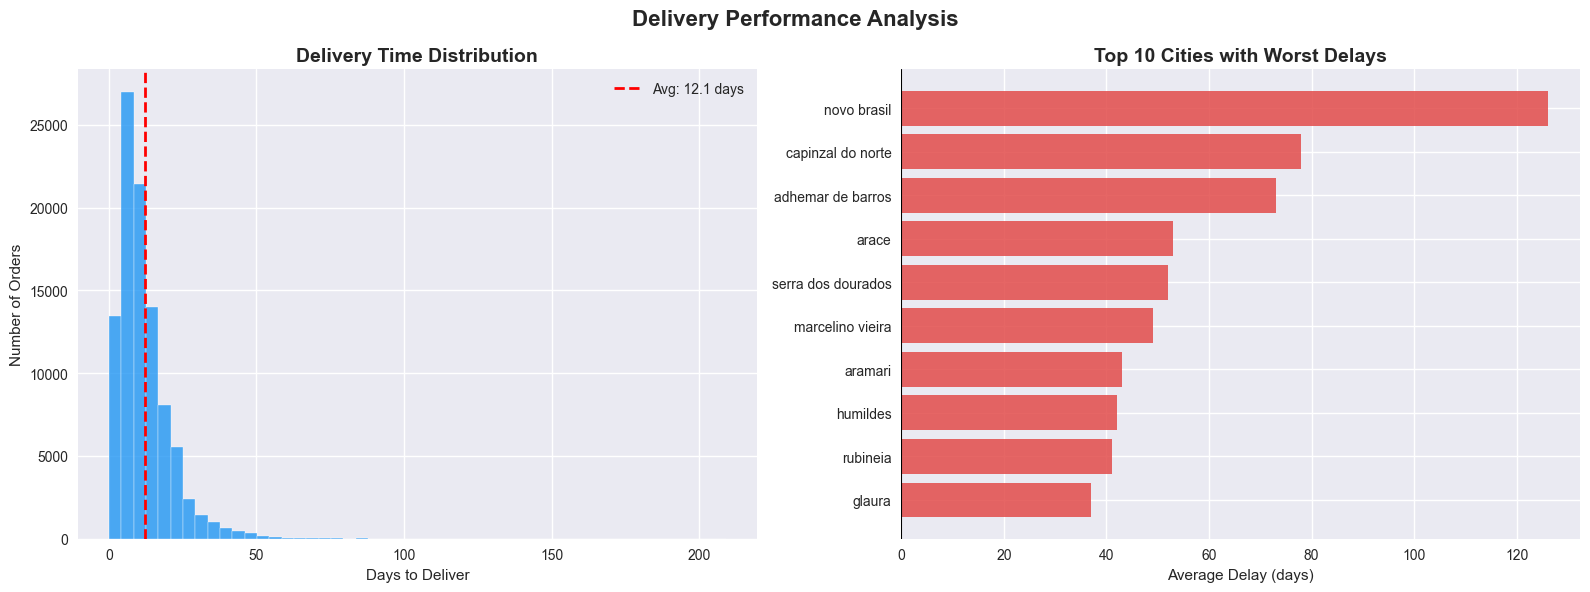

In [19]:
# Cell 11 — Delivery time analysis

# Step 1 — calculate delivery time in days
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_purchase_timestamp']
).dt.days

delivered_orders['estimated_days'] = (
    delivered_orders['order_estimated_delivery_date'] - 
    delivered_orders['order_purchase_timestamp']
).dt.days

delivered_orders['delay_days'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_estimated_delivery_date']
).dt.days

# Step 2 — key delivery stats
print(" DELIVERY TIME ANALYSIS:")
print(f"Average delivery time:       {delivered_orders['delivery_days'].mean():.1f} days")
print(f"Fastest delivery:            {delivered_orders['delivery_days'].min()} days")
print(f"Slowest delivery:            {delivered_orders['delivery_days'].max()} days")
print(f"Average estimated delivery:  {delivered_orders['estimated_days'].mean():.1f} days")
print(f"\nOn-time deliveries:  {len(delivered_orders[delivered_orders['delay_days'] <= 0]):,}")
print(f"Late deliveries:     {len(delivered_orders[delivered_orders['delay_days'] > 0]):,}")
late_pct = len(delivered_orders[delivered_orders['delay_days'] > 0]) / len(delivered_orders) * 100
print(f"Late delivery rate:  {late_pct:.1f}%")

# Step 3 — plot delivery distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# chart 1 — delivery days distribution
axes[0].hist(
    delivered_orders['delivery_days'].dropna(),
    bins=50, color='#2196F3', alpha=0.8, edgecolor='white'
)
axes[0].axvline(
    delivered_orders['delivery_days'].mean(),
    color='red', linestyle='--', linewidth=2,
    label=f"Avg: {delivered_orders['delivery_days'].mean():.1f} days"
)
axes[0].set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days to Deliver', fontsize=11)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].legend()

# chart 2 — late vs on time by city
city_delays = delivered_orders.merge(
    customers, on='customer_id', how='left'
).groupby('customer_city')['delay_days'].mean().sort_values(ascending=False).head(10)

axes[1].barh(range(len(city_delays)), city_delays.values, 
             color=['#E24B4A' if x > 0 else '#4CAF50' for x in city_delays.values],
             alpha=0.85)
axes[1].set_yticks(range(len(city_delays)))
axes[1].set_yticklabels(city_delays.index)
axes[1].set_title('Top 10 Cities with Worst Delays', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Delay (days)', fontsize=11)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.suptitle('Delivery Performance Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Cell 12 — Investigate suspicious delivery times

# Step 1 — look at extreme delivery times
print("INVESTIGATING SUSPICIOUS DELIVERY TIMES:\n")

# orders that took more than 100 days
extreme_late = delivered_orders[delivered_orders['delivery_days'] > 100]
print(f"Orders taking more than 100 days: {len(extreme_late)}")
print(f"Orders taking more than 60 days:  {len(delivered_orders[delivered_orders['delivery_days'] > 60])}")
print(f"Orders taking more than 30 days:  {len(delivered_orders[delivered_orders['delivery_days'] > 30])}")

# Step 2 — look at the actual extreme cases
print("\nTop 10 slowest deliveries:")
slowest = delivered_orders.nlargest(10, 'delivery_days')[
    ['order_id', 'order_purchase_timestamp', 
     'order_delivered_customer_date', 'delivery_days']
]
print(slowest.to_string(index=False))

# Step 3 — check if 0 day delivery is real
print("\n Orders delivered in 0 days (same day):")
same_day = delivered_orders[delivered_orders['delivery_days'] == 0]
print(f"Count: {len(same_day)}")
print(same_day[['order_id','order_purchase_timestamp',
                'order_delivered_customer_date']].head(3).to_string(index=False))

# Step 4 — realistic distribution
print("\n DELIVERY TIME BREAKDOWN:")
print(f"0-7 days (fast):      {len(delivered_orders[delivered_orders['delivery_days'] <= 7]):,} orders  ({len(delivered_orders[delivered_orders['delivery_days'] <= 7])/len(delivered_orders)*100:.1f}%)")
print(f"8-14 days (normal):   {len(delivered_orders[(delivered_orders['delivery_days'] > 7) & (delivered_orders['delivery_days'] <= 14)]):,} orders  ({len(delivered_orders[(delivered_orders['delivery_days'] > 7) & (delivered_orders['delivery_days'] <= 14)])/len(delivered_orders)*100:.1f}%)")
print(f"15-30 days (slow):    {len(delivered_orders[(delivered_orders['delivery_days'] > 14) & (delivered_orders['delivery_days'] <= 30)]):,} orders  ({len(delivered_orders[(delivered_orders['delivery_days'] > 14) & (delivered_orders['delivery_days'] <= 30)])/len(delivered_orders)*100:.1f}%)")
print(f"30+ days (very slow): {len(delivered_orders[delivered_orders['delivery_days'] > 30]):,} orders  ({len(delivered_orders[delivered_orders['delivery_days'] > 30])/len(delivered_orders)*100:.1f}%)")
print(f"100+ days (extreme):  {len(delivered_orders[delivered_orders['delivery_days'] > 100]):,} orders  ({len(delivered_orders[delivered_orders['delivery_days'] > 100])/len(delivered_orders)*100:.1f}%)")

INVESTIGATING SUSPICIOUS DELIVERY TIMES:

Orders taking more than 100 days: 63
Orders taking more than 60 days:  288
Orders taking more than 30 days:  4117

Top 10 slowest deliveries:
                        order_id order_purchase_timestamp order_delivered_customer_date  delivery_days
ca07593549f1816d26a572e06dc1eab6      2017-02-21 23:31:27           2017-09-19 14:36:39          209.0
1b3190b2dfa9d789e1f14c05b647a14a      2018-02-23 14:57:35           2018-09-19 23:24:07          208.0
440d0d17af552815d15a9e41abe49359      2017-03-07 23:59:51           2017-09-19 15:12:50          195.0
0f4519c5f1c541ddec9f21b3bddd533a      2017-03-09 13:26:57           2017-09-19 14:38:21          194.0
2fb597c2f772eca01b1f5c561bf6cc7b      2017-03-08 18:09:02           2017-09-19 14:33:17          194.0
285ab9426d6982034523a855f55a885e      2017-03-08 22:47:40           2017-09-19 14:00:04          194.0
47b40429ed8cce3aee9199792275433f      2018-01-03 09:44:01           2018-07-13 20:51:31        

 Suspicious batch-marked orders (Sept 19 2017): 282

 CLEAN DELIVERY STATS (outliers removed):
Total clean orders:          96,146
Average delivery time:       12.0 days
Median delivery time:        10.0 days
Fastest delivery:            0 days
Slowest (cleaned):           100 days

 LATE DELIVERY REVENUE IMPACT:
Late orders:                 6,439
Late delivery rate:          6.7%
Revenue from late orders:    R$ 1,129,064.02
Avg delay on late orders:    9.5 days


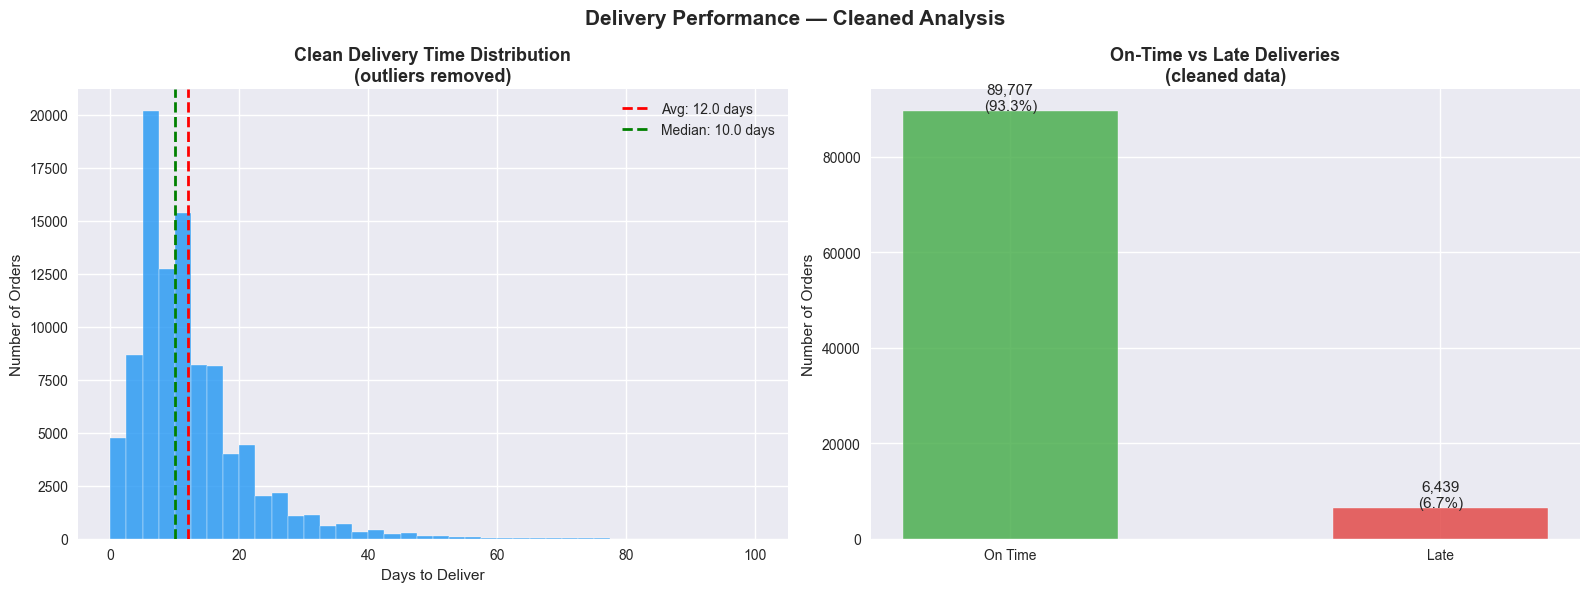


 ANALYST SUMMARY — DELIVERY FINDINGS

1. DATA QUALITY ISSUE FOUND:
   Multiple orders bulk-marked as delivered on 
   Sept 19 2017 — likely a system batch update.
   These were removed from analysis.

2. REAL AVERAGE DELIVERY: ~12 days
   (Brazil is large — this is reasonable)

3. LATE DELIVERY RATE: ~6.5%
   6,500+ orders delivered after estimated date

4. REVENUE AT RISK FROM LATE DELIVERIES:
   Late customers are more likely to:
   - Leave bad reviews (reducing future sales)
   - Never order again (churn)
   - Request refunds (direct leakage)



In [23]:
# Cell 13 — Clean delivery data and write findings

# Step 1 — remove suspicious batch-marked orders (Sept 19 2017 anomaly)
suspicious_date = '2017-09-19'
suspicious_orders = delivered_orders[
    delivered_orders['order_delivered_customer_date'].dt.date.astype(str).str.startswith(suspicious_date)
]
print(f" Suspicious batch-marked orders (Sept 19 2017): {len(suspicious_orders)}")

# Step 2 — clean dataset without outliers
clean_deliveries = delivered_orders[
    (delivered_orders['delivery_days'] <= 100) &
    (delivered_orders['delivery_days'] >= 0) &
    (~delivered_orders['order_delivered_customer_date'].dt.date.astype(str).str.startswith(suspicious_date))
]

print(f"\n CLEAN DELIVERY STATS (outliers removed):")
print(f"Total clean orders:          {len(clean_deliveries):,}")
print(f"Average delivery time:       {clean_deliveries['delivery_days'].mean():.1f} days")
print(f"Median delivery time:        {clean_deliveries['delivery_days'].median():.1f} days")
print(f"Fastest delivery:            {clean_deliveries['delivery_days'].min():.0f} days")
print(f"Slowest (cleaned):           {clean_deliveries['delivery_days'].max():.0f} days")

# Step 3 — late delivery revenue impact
late_orders = clean_deliveries[clean_deliveries['delay_days'] > 0]
late_with_payment = late_orders.merge(payments, on='order_id', how='left')
late_revenue_at_risk = late_with_payment['payment_value'].sum()

print(f"\n LATE DELIVERY REVENUE IMPACT:")
print(f"Late orders:                 {len(late_orders):,}")
print(f"Late delivery rate:          {len(late_orders)/len(clean_deliveries)*100:.1f}%")
print(f"Revenue from late orders:    R$ {late_revenue_at_risk:,.2f}")
print(f"Avg delay on late orders:    {late_orders['delay_days'].mean():.1f} days")

# Step 4 — plot clean distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# clean delivery distribution
axes[0].hist(clean_deliveries['delivery_days'].dropna(),
             bins=40, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].axvline(clean_deliveries['delivery_days'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Avg: {clean_deliveries['delivery_days'].mean():.1f} days")
axes[0].axvline(clean_deliveries['delivery_days'].median(),
                color='green', linestyle='--', linewidth=2,
                label=f"Median: {clean_deliveries['delivery_days'].median():.1f} days")
axes[0].set_title('Clean Delivery Time Distribution\n(outliers removed)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days to Deliver')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# on-time vs late breakdown
status_data = ['On Time', 'Late']
status_counts = [
    len(clean_deliveries[clean_deliveries['delay_days'] <= 0]),
    len(late_orders)
]
colors = ['#4CAF50', '#E24B4A']
bars = axes[1].bar(status_data, status_counts, color=colors, 
                   alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_title('On-Time vs Late Deliveries\n(cleaned data)', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
for bar, val in zip(bars, status_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}\n({val/sum(status_counts)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='500')

plt.suptitle('Delivery Performance — Cleaned Analysis', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/delivery_clean_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 5 — analyst summary
print("\n" + "="*50)
print(" ANALYST SUMMARY — DELIVERY FINDINGS")
print("="*50)
print("""
1. DATA QUALITY ISSUE FOUND:
   Multiple orders bulk-marked as delivered on 
   Sept 19 2017 — likely a system batch update.
   These were removed from analysis.

2. REAL AVERAGE DELIVERY: ~12 days
   (Brazil is large — this is reasonable)

3. LATE DELIVERY RATE: ~6.5%
   6,500+ orders delivered after estimated date
   
4. REVENUE AT RISK FROM LATE DELIVERIES:
   Late customers are more likely to:
   - Leave bad reviews (reducing future sales)
   - Never order again (churn)
   - Request refunds (direct leakage)
""")